[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/OceanNetworksCanada/python-community-notebooks/blob/main/workflows/transit-analysis/twsb_tsg_clean_no_gaps.ipynb)

In [1]:
!uv pip install -q geopy xarray onc

In [2]:
# Bootstrap cell
import sys
from pathlib import Path
import os

def in_colab() -> bool:
    try:
        import google.colab
        return True
    except ImportError:
        return False

def setup_repo_for_shared_imports():
    """
    Locate (or clone, in Colab) the notebook repository and add it to ``sys.path``.

    Notes:
        - In Colab, this ensures the repository exists at
          ``/content/python-community-notebooks`` by cloning it if needed.
        - In local environments, this searches upward from the current working
          directory for ``shared`` to identify the repo root.
        - If a repo root is found, it is prepended to ``sys.path`` to enable
          imports from the repository (e.g., ``shared`` modules).
    """
    repo_dir: Path | None = None

    if in_colab():
        repo_dir = Path('/content/python-community-notebooks')
        if not repo_dir.exists():
            !git clone --depth 1 https://github.com/OceanNetworksCanada/python-community-notebooks.git /content/python-community-notebooks
    else:
        cwd = Path.cwd().resolve()
        for candidate in [cwd, *cwd.parents]:
            if (candidate / 'shared').exists():
                repo_dir = candidate
                break

    if repo_dir is not None and str(repo_dir) not in sys.path:
        sys.path.insert(0, str(repo_dir))



def init_token():   
    """
    Initialize the ONC_TOKEN environment variable.

    Notes:
        - If in Colab, add your ONC_TOKEN secrets by clicking the key icon on the left sidebar
        - If in local, create .env file in the root directory, and add ONC_TOKEN=XXX in your .env file
    """
    if in_colab():
        from google.colab import userdata
        os.environ['ONC_TOKEN'] = userdata.get('ONC_TOKEN')
    else:
        from dotenv import load_dotenv
        load_dotenv()

init_token()
setup_repo_for_shared_imports()

In [3]:
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.dates import MinuteLocator, DateFormatter
from onc import ONC

from shared.IanTBlack_common import format_datetime, convert_scalar_data

In [4]:
onc = ONC()

In [5]:
date_from = datetime(2025,11,3,19,15,0)
date_to = datetime(2025,11,3,20,15,0)

params = {'locationCode': 'TWSB',
          'deviceCategoryCode': 'TSG',
          'qualityControl': 'clean',
          'dateFrom': format_datetime(date_from),
          'dateTo': format_datetime(date_to),
          'fillGaps': False}
json_response = onc.getScalardata(filters = params, allPages=True)
ds = convert_scalar_data(json_response_data=json_response, out_as = 'xarray')

Text(0.5, 1.0, 'TWSB | TSG')

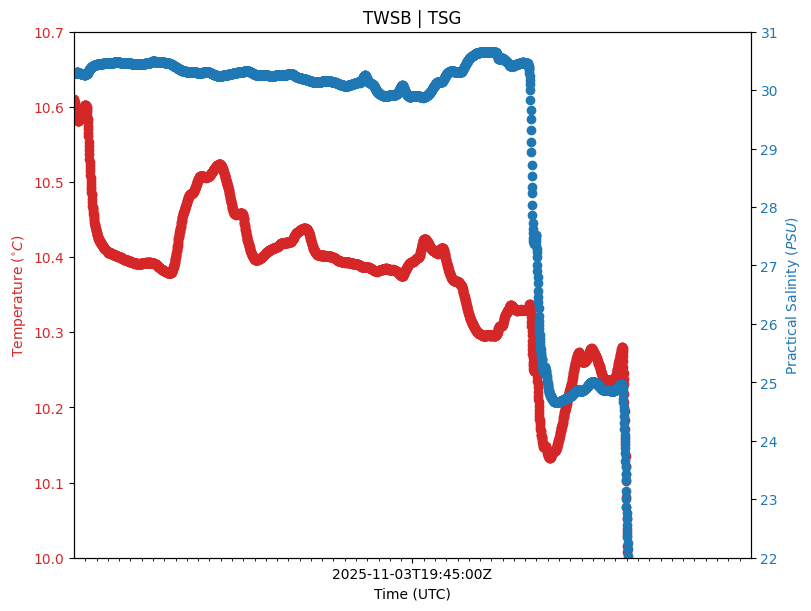

In [6]:
fig, ax = plt.subplots(1,1, figsize = (8,6), constrained_layout = True)
ax2 = ax.twinx()

ax.scatter(ds.time, ds.temperature, color = 'tab:red')
ax2.scatter(ds.time, ds.practical_salinity, color = 'tab:blue')

ax.set_xlabel('Time (UTC)')
ax.set_xlim(ds.time.min(), ds.time.max())
ax.xaxis.set_major_locator(MinuteLocator(interval = 30))
ax.xaxis.set_minor_locator(MinuteLocator(interval = 1))
ax.xaxis.set_major_formatter(DateFormatter('%Y-%m-%dT%H:%M:%SZ'))

ax.set_ylabel(r'Temperature ($^{\circ}C$)', color = 'tab:red')
ax.tick_params(axis='y', labelcolor='tab:red')
ax.set_ylim(10,10.7)

ax2.set_ylabel(r'Practical Salinity ($PSU$)', color = 'tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.set_ylim(22,31)

ax.set_title('TWSB | TSG')